In [118]:
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

load_dotenv()

True

In [119]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [120]:
# defining the max tokens
MAX_TOKENS = 100

In [121]:
def chat_node_trimmer(state: MessagesState):

    #triming before calling the messages

    messages = trim_messages(
        state['messages'],
        strategy='last', 
        token_counter=count_tokens_approximately, 
        max_tokens=MAX_TOKENS)
    
    print("Number of tokens in the messages:", count_tokens_approximately(messages=messages))
    
    response = LLM.invoke(messages)
    return {'messages': [response]}

In [122]:
# building the graph
graph = StateGraph(MessagesState)

graph.add_node("chat_node", chat_node_trimmer)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

checkpoint = InMemorySaver()
Triming_STM = graph.compile(checkpointer=checkpoint)

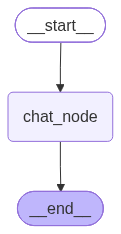

In [123]:
from IPython.display import Image
Image(Triming_STM.get_graph().draw_mermaid_png())

In [124]:
#creating the thread id for the chat
config1 = {"configurable": {"thread_id": "chat-2"}}

In [125]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "hi"}]}, config1)

Number of tokens in the messages: 5


In [126]:
result['messages'][-1].content

'Hello! How can I help you today?'

In [127]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "i am learning about langgraph"}]}, config1)

Number of tokens in the messages: 31


In [128]:
result['messages'][-1].content

'That’s great! LangGraph is a powerful library for building **graph‑structured** workflows with LLMs (large language models). It lets you compose complex, multi‑step “agentic” applications where each node in the graph can be a prompt, a tool call, a conditional branch, a loop, etc. Below is a quick crash‑course to get you up and running, plus some pointers for deeper dives.\n\n---\n\n## 1. Core Concepts\n\n| Concept | What it is | Typical Use‑Case |\n|---------|------------|------------------|\n| **Node** | A callable (often a `Runnable` or a `Tool`) that takes an input dict and returns an output dict. | Prompt → LLM call, API request, data transformation |\n| **Edge** | A directed connection that determines the next node(s) based on the current state. | “If the user asks for weather → go to `fetch_weather` node; else → go to `fallback` node.” |\n| **State** | A mutable dictionary that flows through the graph, accumulating context, intermediate results, and metadata. | Store conversati

In [129]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "can you write a 10 line paragraph on langgraph?"}]}, config1)

Number of tokens in the messages: 16


In [130]:
result["messages"][-1].content

'LangGraph is an open‑source framework that lets developers build, visualize, and manage complex LLM‑driven workflows as directed graphs.  \nEach node in a LangGraph represents a distinct processing step—prompt generation, tool invocation, or result aggregation—allowing fine‑grained control over the model’s reasoning path.  \nThe library abstracts away boilerplate state handling, so developers can focus on the logical flow rather than on low‑level prompt stitching.  \nBecause the graph structure is explicit, debugging becomes intuitive: you can trace exactly which node produced a given output and why.  \nLangGraph supports conditional branching, loops, and parallel execution, making it suitable for both simple question‑answering pipelines and sophisticated multi‑agent systems.  \nIntegration with popular LLM providers (OpenAI, Anthropic, Cohere) is seamless, and custom nodes can wrap any Python function or external API.  \nThe framework also offers built‑in persistence, enabling long‑r

In [131]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "hello how are you what are you doing can you name good leetcode algorithms for my interview tomorrow?"}]}, config1)

Number of tokens in the messages: 30


In [132]:
result["messages"][-1].content

'Hey there! I’m doing great, thanks for asking. Hope you’re feeling ready for your interview tomorrow – a little prep can go a long way. Below is a compact “cheat‑sheet” of the most frequently tested algorithmic topics on LeetCode, along with a few standout problems (sorted by difficulty) that will help you practice the core ideas and patterns.\n\n---\n\n## 1. Arrays & Strings\n| Pattern | What to master | Sample LeetCode problems |\n|---------|----------------|--------------------------|\n| Two‑pointer / sliding window | Sorting‑free linear scans, handling duplicates, variable‑size windows | **Easy:** 1️⃣ *Two Sum* (array), 3️⃣ *Longest Substring Without Repeating Characters* <br> **Medium:** 15️⃣ *3Sum*, 76️⃣ *Minimum Window Substring* |\n| Prefix sums / difference array | Range‑sum queries, “subarray equals k” | 560️⃣ *Subarray Sum Equals K* |\n| In‑place array manipulation | Rotate, reverse, partition | 189️⃣ *Rotate Array*, 215️⃣ *Kth Largest Element in an Array* |\n| String hashi